In [1]:
import numpy as np
#import torch
#import jax
#import jax.numpy as jnp
# mute this since it requires py3.8 and py3.10 env, not default py3.11
#import tensorflow as tf
import iree.compiler
import iree.runtime
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# IREE version: candidate-20230815.614

# Input: BMM 8x512x1024x512

In [2]:
!cat ../operator-cases/matmul_32x512x1024x512.mlir
!../../build/bin/ragdoll-opt \
    ../operator-cases/matmul_32x512x1024x512.mlir \
    --pass-pipeline="builtin.module(func.func( \
    tosa-to-linalg-named \
))" > ../../build/.batch_matmul.mlir.linalg
!cat ../../build/.batch_matmul.mlir.linalg

module {
  func.func @matmul(%arg0: tensor<32x512x1024xf32>, %arg1: tensor<32x1024x512xf32>) -> tensor<32x512x512xf32> {
    %0 = tosa.matmul %arg0, %arg1 : (tensor<32x512x1024xf32>, tensor<32x1024x512xf32>) -> tensor<32x512x512xf32>
    return %0 : tensor<32x512x512xf32>
  }
}
module {
  func.func @matmul(%arg0: tensor<32x512x1024xf32>, %arg1: tensor<32x1024x512xf32>) -> tensor<32x512x512xf32> {
    %cst = arith.constant 0.000000e+00 : f32
    %0 = tensor.empty() : tensor<32x512x512xf32>
    %1 = linalg.fill ins(%cst : f32) outs(%0 : tensor<32x512x512xf32>) -> tensor<32x512x512xf32>
    %2 = linalg.batch_matmul ins(%arg0, %arg1 : tensor<32x512x1024xf32>, tensor<32x1024x512xf32>) outs(%1 : tensor<32x512x512xf32>) -> tensor<32x512x512xf32>
    return %2 : tensor<32x512x512xf32>
  }
}



# Baseline: Default IREE codegen solution

In [3]:
# compile baseline ragdoll matmul
!nohup iree-compile ../../build/.batch_matmul.mlir.linalg \
-o ../../build/.batch_matmul.vmfb \
--mlir-print-ir-after-all \
--iree-hal-target-backends=cuda \
--iree-hal-cuda-llvm-target-arch=sm_70 > ../../build/basic_dump.mlir 2>&1

# DIY: Configure Matmul Kernel with JIT-recipe

In [4]:
!iree-compile ../../build/.batch_matmul.mlir.linalg \
--compile-from=input \
--compile-to=executable-sources \
--iree-hal-target-backends=cuda \
--iree-opt-const-eval=1 \
--iree-opt-const-expr-hoisting=1 \
--iree-opt-numeric-precision-reduction=1 \
--iree-hal-cuda-llvm-target-arch=sm_86 > ../../build/.batch_matmul.mlir.executable-sources
!cat ../../build/.batch_matmul.mlir.executable-sources

module attributes {hal.device.targets = [#hal.device.target<"cuda", {executable_targets = [#hal.executable.target<"cuda", "cuda-nvptx-fb", {target_arch = "sm_86"}>]}>]} {
  hal.executable private @matmul_dispatch_0 {
    hal.executable.variant public @cuda_nvptx_fb target(<"cuda", "cuda-nvptx-fb", {target_arch = "sm_86"}>) {
      hal.executable.export public @matmul_dispatch_0_batch_matmul_32x512x512x1024_f32 ordinal(0) layout(#hal.pipeline.layout<push_constants = 0, sets = [<0, bindings = [<0, storage_buffer, ReadOnly>, <1, storage_buffer, ReadOnly>, <2, storage_buffer>]>]>) {
      ^bb0(%arg0: !hal.device):
        %x, %y, %z = flow.dispatch.workgroup_count_from_slice 
        hal.return %x, %y, %z : index, index, index
      }
      builtin.module {
        func.func @matmul_dispatch_0_batch_matmul_32x512x512x1024_f32() {
          %cst = arith.constant 0.000000e+00 : f32
          %c0 = arith.constant 0 : index
          %0 = hal.interface.binding.subspan set(0) binding(0) type(st

In [5]:
!iree-opt ../../build/.batch_matmul.mlir.executable-sources \
--pass-pipeline="builtin.module(hal.executable(hal.executable.variant(iree-llvmgpu-select-lowering-strategy)))" \
--iree-codegen-llvmgpu-enable-transform-dialect-batch-matmul-strategy \
--iree-codegen-llvmgpu-enable-transform-dialect-jit=1 \
--td-matmul-strategy-blk-sizes=8,32,16,64 \
--td-matmul-strategy-reduc-size=8 \
--td-matmul-strategy-num-threads=32,8,1 \
--td-matmul-strategy-num-warps=1,8,1 \
--td-matmul-strategy-pipeline-depth=3 \
--td-matmul-strategy-use-mma-sync=true \
--td-matmul-strategy-use-wmma=false \
--iree-hal-target-backends=cuda \
--iree-hal-cuda-llvm-target-arch=sm_86 > ../../build/.batch_matmul.mlir.executable-configurations
!cat ../../build/.batch_matmul.mlir.executable-configurations

#config = #iree_codegen.lowering_config<tile_sizes = [[1, 32, 32, 16]]>
#executable_target_cuda_nvptx_fb = #hal.executable.target<"cuda", "cuda-nvptx-fb", {target_arch = "sm_86"}>
#pipeline_layout = #hal.pipeline.layout<push_constants = 0, sets = [<0, bindings = [<0, storage_buffer, ReadOnly>, <1, storage_buffer, ReadOnly>, <2, storage_buffer>]>]>
#translation = #iree_codegen.translation_info<LLVMGPUMatmulTensorCoreMmaSync, {pipeline_depth = 4 : i64, store_stage = 1 : i64}>
#device_target_cuda = #hal.device.target<"cuda", {executable_targets = [#executable_target_cuda_nvptx_fb]}>
module attributes {hal.device.targets = [#device_target_cuda]} {
  hal.executable private @matmul_dispatch_0 {
    hal.executable.variant public @cuda_nvptx_fb target(#executable_target_cuda_nvptx_fb) {
      hal.executable.export public @matmul_dispatch_0_batch_matmul_32x512x512x1024_f32 ordinal(0) layout(#pipeline_layout) attributes {subgroup_size = 32 : index, translation_info = #translation, workgroup_size

In [6]:
# other input format is illegal for iree-compile
!iree-compile ../../build/.batch_matmul.mlir.executable-configurations \
-o ../../build/.batch_matmul.candidate1.vmfb \
--compile-from=executable-configurations \
--iree-hal-target-backends=cuda \
--iree-hal-cuda-llvm-target-arch=sm_86


# Benchmarking
We use python bindings to profiling, you can also use command-line tools as follows:
* !iree-compile ../../build/.matmul.mlir.linalg \
    -o ../../build/.matmul.vmfb \
    --iree-hal-target-backends=cuda \
    --iree-hal-cuda-llvm-target-arch=sm_70
    
* !nohup iree-run-module \
    --device=cuda \
    --module="../../build/.matmul.vmfb" \
    --function=matmul \
    --input="2x512x1024xf32=0.01" \
    --input="2x1024x512xf32=0.01" > ../../build/.output 2>&1

/tmp/ipykernel_2829413/704423794.py:30: UserWarning: Making copy of unaligned VmModule buffer. It is recommended to make this deterministic by calling `copy_buffer` to always make a copy or `mmap` to efficiently load from a file. This warning can be silenced by adding `warn_if_copy=False` to `from_buffer`
  vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)


<VmModule module : [matmul, __init]>
<BoundModule <VmModule module : [matmul, __init]>>
<VmModule module : [matmul, __init]>
<BoundModule <VmModule module : [matmul, __init]>>


Text(0.5, 0.98, 'Time Cost')

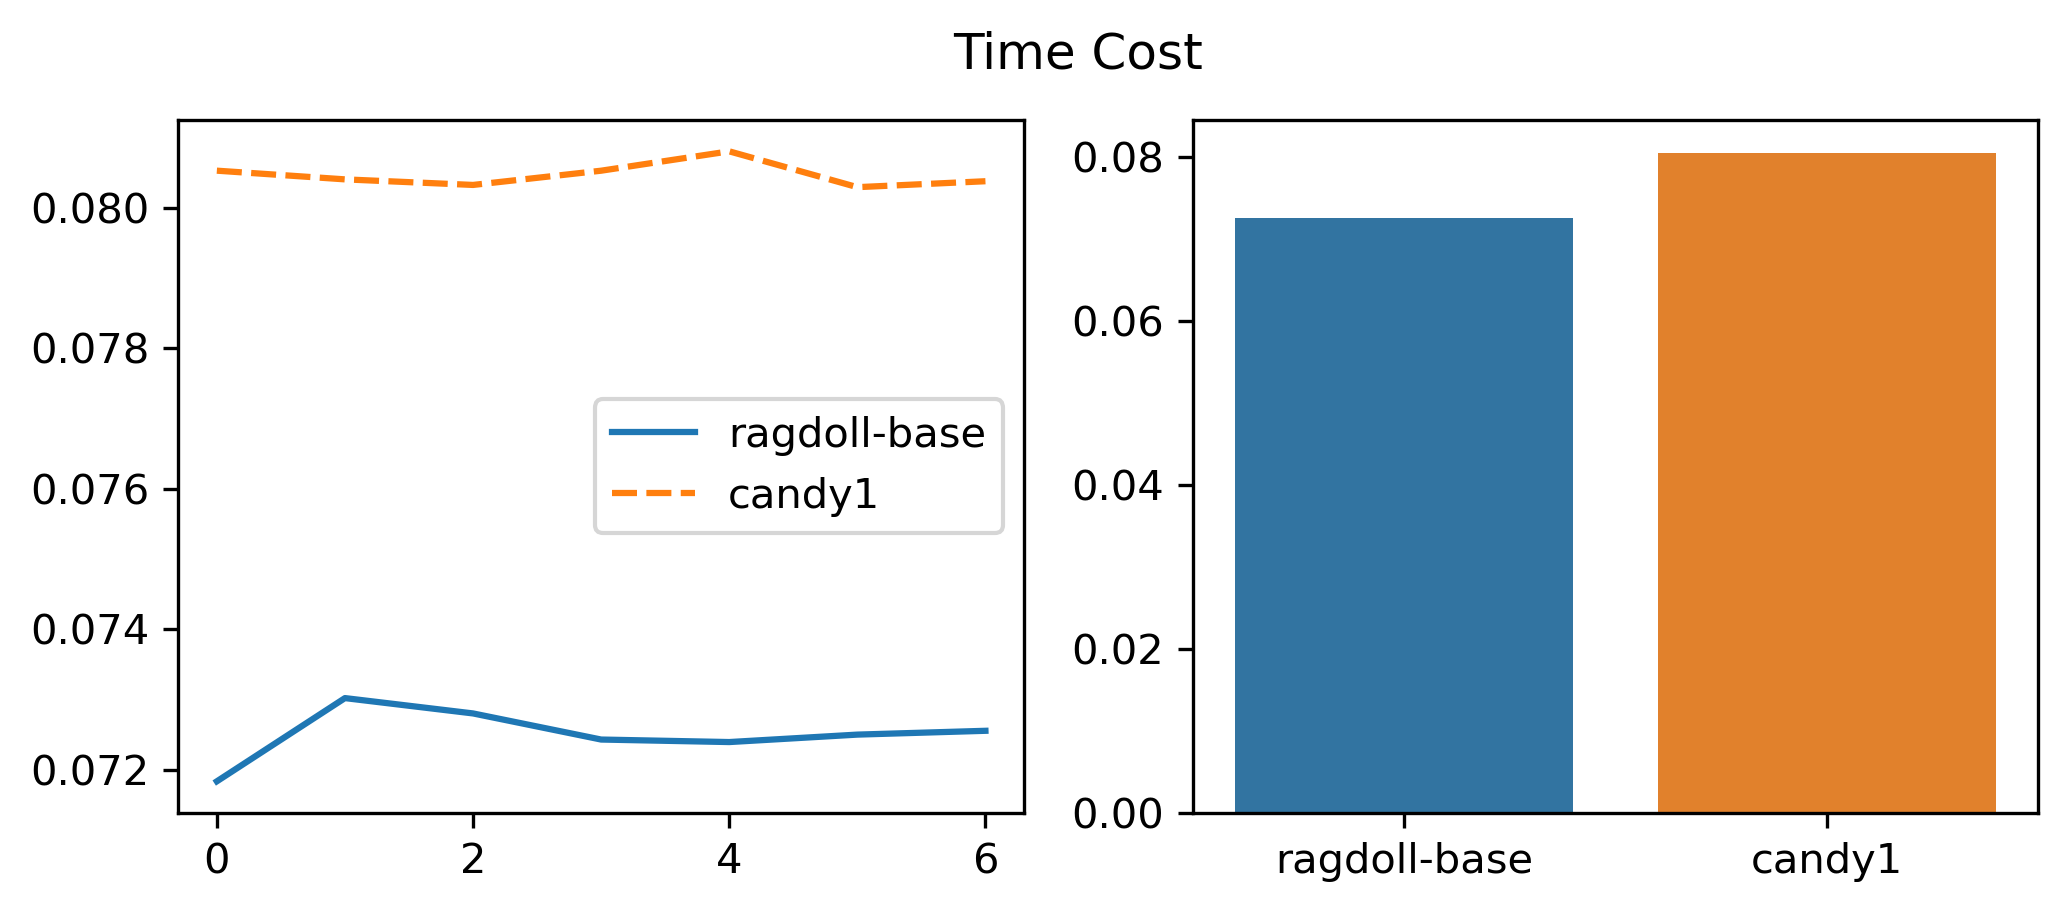

In [7]:
def iree_compile(workload_ir, input_type):
    #binary = iree.compiler.tools.compile_str(
    #    module, input_type="tosa", target_backends=["llvm-cpu"]
    #)
    #binary = iree.compiler.tools.compile_file(
    #    workload_ir, input_type=input_type, target_backends=["cuda"]
    #)
    #CPU
    #config = iree.runtime.system_api.Config("local-task")
    #GPU
    config = iree.runtime.system_api.Config("cuda")
    vmi = iree.runtime.VmInstance()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary)
    vmo = iree.runtime.load_vm_module(vmm, config)
    return vmo
def iree_load(workload_fb, input_type):
    #binary = iree.compiler.tools.compile_str(
    #    module, input_type="tosa", target_backends=["llvm-cpu"]
    #)
    #binary = iree.compiler.tools.compile_file(
    #    workload_ir, input_type=input_type, target_backends=["cuda"]
    #)
    #CPU
    #config = iree.runtime.system_api.Config("local-task")
    #GPU
    config = iree.runtime.system_api.Config("cuda")
    vmi = iree.runtime.VmInstance()
    with open(workload_fb, 'rb') as file:
      binary_data = file.read()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
    print(vmm)
    vmo = iree.runtime.load_vm_module(vmm, config)
    print(vmo)
    return vmo
#base_iree_module = iree_compile(workload_ir="../../build/.matmul.mlir.linalg", input_type="tosa")
#candy1_iree_module = iree_compile(workload_ir="../../build/.matmul.candidate1.vmfb", input_type="tosa")
base_iree_module = iree_load(workload_fb="../../build/.batch_matmul.vmfb", input_type="tosa")
candy1_iree_module = iree_load(workload_fb="../../build/.batch_matmul.candidate1.vmfb", input_type="auto")

from functools import wraps
from time import perf_counter
from collections import namedtuple

TestResult = namedtuple("TestResult", ("res", "forward_timecost"))


TimerResult = namedtuple("TimerResult", ("result", "timecost"))

def timer(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = perf_counter()
        res = func(*args, **kwargs)
        end = perf_counter()
        \
        return TimerResult(res, end - start)
    return wrapper

def torch_test(lhs, rhs):
    lhs, rhs = [torch.from_numpy(i) for i in [lhs, rhs]]
    lhs.requires_grad = True
    rhs.requires_grad = True
    
    @timer
    def forward():
        return torch.bmm(lhs, rhs)
    
    res, forward_timecost = forward()
    
    return TestResult(res, forward_timecost)
    
def base_iree_test(lhs, rhs):
    @timer
    def forward():
        return base_iree_module["matmul"](lhs, rhs)[0]
    
    res, timecost = forward()
    return TestResult(res, timecost)

def candy1_iree_test(lhs, rhs):
    @timer
    def forward():
        return candy1_iree_module["matmul"](lhs, rhs)[0]
    
    res, timecost = forward()
    return TestResult(res, timecost)

def test_all_ntimes(n):
    lhs_list = [np.random.randn(32, 512, 1024).astype(np.float32) for _ in range(n)]
    rhs_list = [np.random.randn(32, 1024, 512).astype(np.float32) for _ in range(n)]
    
    def test(func):
        test_results = []
        for lhs, rhs in zip(lhs_list, rhs_list):
            test_results.append(func(lhs, rhs))
        return test_results
    # use python 310 env templly
    #torch_result = test(torch_test)
    base_iree_result = test(base_iree_test)
    candy1 = test(candy1_iree_test)
    #return torch_result, base_iree_result, candy1
    return base_iree_result, candy1
    
# names = ["torch 2.0.1", "ragdoll-base", "candy1"]
names = ["ragdoll-base", "candy1"]
def get_forward_array(res):
    return np.array(list(map(lambda x : x.forward_timecost, res)))[4:]

results = test_all_ntimes(11)
forward_line = pd.DataFrame(dict(zip(names, [get_forward_array(res) for res in results])))
forward_bar = pd.DataFrame(dict(zip(names, [[np.mean(get_forward_array(res))] for res in results])))

plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.figsize"] = (3, 3)

fig, (left, right) = plt.subplots(ncols=2, figsize=(8, 3))
sns.lineplot(forward_line, ax=left)
sns.barplot(forward_bar, ax=right)
plt.suptitle("Time Cost")